In [32]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cbook, cm
from matplotlib.colors import LightSource

from data_center_model import *
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200

def grid_sample_cost_function(sim_model,
                              workload,
                              util,
                              p_range=[0.7,1.3],
                              r_range=[0.2,1],
                              density=50,
                              dict_location = '../data/python_data/'):
    work_feature_dict = get_workload_mix_features_dict(dict_location)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    sim_model.to(device) # in case it is not already 
    cost_matrix = np.empty((density,density))
    p_matrix = np.empty((density,density))
    r_matrix = np.empty((density,density))
    for i,p in enumerate(np.linspace(p_range[0],p_range[1],density)):
        for j,r in enumerate(np.linspace(r_range[0],r_range[1],density)):
            # running model, getting cost
            x_workloads = torch.tensor(work_feature_dict[workload]).unsqueeze(0).float().to(device)
            x_sim_config = torch.tensor(float(util)).to(device).unsqueeze(0)
            x_p = torch.tensor(float(p)).to(device).unsqueeze(0)
            x_r = torch.tensor(float(r)).to(device).unsqueeze(0)
            cost = sim_model.forward(x_workloads,x_sim_config,x_p,x_r)
            # adding things to our plotting matrices
            cost_matrix[i,j] = cost.item()
            p_matrix[i,j] = p
            r_matrix[i,j] = r
    # plotting proper
    # Set up plot
    fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))

    ls = LightSource(270, 45)
    # To use a custom hillshading mode, override the built-in shading and pass
    # in the rgb colors of the shaded surface calculated from "shade".
    # for reference https://matplotlib.org/stable/users/explain/colors/colormaps.html
    scamap = plt.cm.ScalarMappable(cmap='viridis')
    # ones I like are - gnuplot, viridis, plasma
    # ones that are ok - rainbow, inferno
    fcolors = scamap.to_rgba(cost_matrix)
    p_matrix = p_matrix * 151550/1000
    r_matrix = r_matrix * 41905.125715377/1000
    
    surf = ax.plot_surface(p_matrix, r_matrix, cost_matrix, rstride=1, cstride=1, facecolors=fcolors,
                        linewidth=0, antialiased=True, shade=False)
    plt.xlabel('Power [kW]', fontsize=15)
    plt.ylabel('Reserve [kW]', fontsize=15)
    plt.ticklabel_format(style='sci',axis='x')
    plt.ticklabel_format(style='sci',axis='y')
    plt.ticklabel_format(style='sci',axis='z')
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    
    ax.set_zlabel('Cost',rotation=90,fontsize=15)
    ax.dist = 12
    ax.tick_params('z',labelsize=11)
    fig.colorbar(scamap,ax=ax,location='left',fraction=0.03, pad=-0.05)
    #plt.title('Cost Landscape: Workload: ' + workload + ', Util:'+ str(util))
    plt.title('Cost Landscape: Workload: ' + workload, fontsize=18)
    #plt.show()
    plt.savefig('cost_landscape_' + workload + '.pdf',bbox_inches='tight')

C:\Users\qtcc\AppData\Local\Temp\ipykernel_12412\3451131158.py:62: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 12


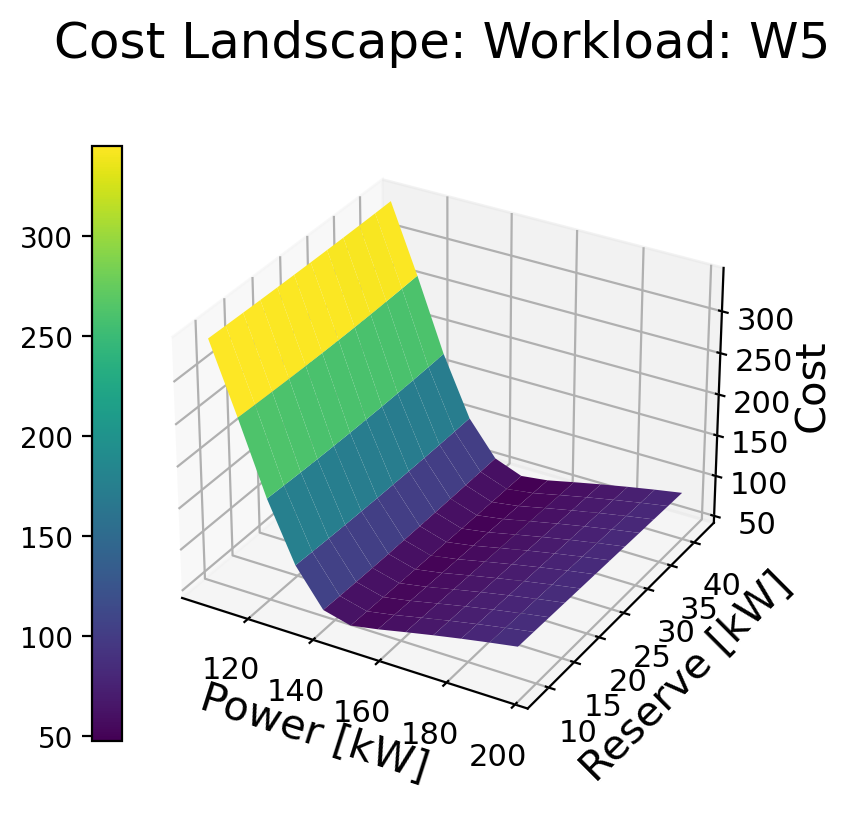

In [33]:
workload = 'W5'
util = 0.8
sim_model = torch.load('models/model_v1.6.pth')
grid_sample_cost_function(sim_model,workload,util,density=12)

In [26]:
plt.savefig('cost_landscape.pdf',format='pdf')

<Figure size 1280x960 with 0 Axes>

In [35]:
# model
## W5
print(0.997*151550)
print(0.57317*41905.125715377)
## W6
print(1.000*171300)
print(0.385*54250)
## W7
print(157675*1.0912)
print(0.5293*45733.33333)

151095.35
24018.760906282634
171300.0
20886.25
172054.96
24206.653331569


In [36]:
# sim
## W5
print(1.007595*151550)
print(0.582944*41905.125715377)
## W6
print(1.000*171300)
print(0.385*54250)
## W7
print(157675*0.960342)
print(0.797015*45733.33333)

152701.02225
24428.34160502473
171300.0
20886.25
151421.92485
36450.152664009955
